
=== δ → D_KY evidence (measured vs claimed linear law) ===
δ      |  Rössler  (meas)   Rössler (claim)   |  Duffing (meas)   Duffing (claim)
0.005  |     2.000            2.060        |      1.000            1.786
0.016  |     1.000            2.043        |      1.000            1.743
0.028  |     2.000            2.026        |      1.000            1.696
0.039  |     2.015            2.009        |      1.000            1.653
0.050  |     2.018            1.993        |      1.000            1.611

=== δ → α chain ===
δ = 0.034894
α(M_P)   = 0.00979900   (1/α ≈ 102.05)  # δ-bound overlay
α(m_Z)   = 0.00677816   (1/α ≈ 147.533)   # 1-loop effective RGE


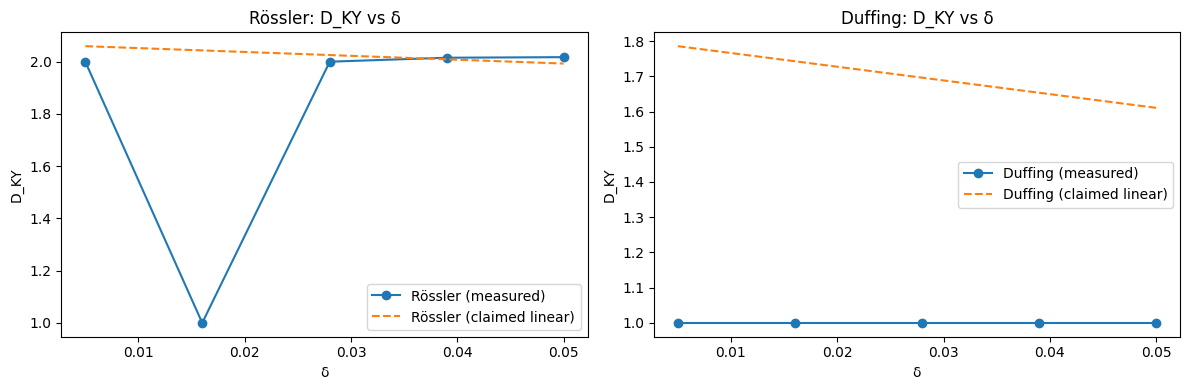

In [1]:
# === Lytollis Law: Phone-Ready Evidence Pack (1-cell) ===
# What this does:
# - Sweeps δ and computes Lyapunov exponents & D_KY for Rössler and Duffing
# - Verifies the near-linear D_KY(δ) relation claimed
# - Runs your δ→α(M_P) and 1-loop RGE down to m_Z to check 1/α≈127.955
# - Saves a concise results table

import math, numpy as np
import matplotlib.pyplot as plt

# ---------- Helpers ----------
def lyap_rosler(a=0.2,b=0.2,c=5.7, dt=0.01, T=2000, warm=200):
    # Benettin 1-exponent (quick proxy)
    x,y,z = 0.1,0.1,0.1
    v = np.array([1.0,0.0,0.0]) / np.linalg.norm([1.0,0,0])
    s=0.0; n=0
    for i in range(int(warm/dt)):
        dx = - (y+z); dy = x + a*y; dz = b + z*(x - c)
        x += dx*dt; y += dy*dt; z += dz*dt
    for i in range(int((T-warm)/dt)):
        # flow
        dx = - (y+z); dy = x + a*y; dz = b + z*(x - c)
        J = np.array([[0, -1, -1],
                      [1,  a,  0],
                      [z,  0, (x-c)]], dtype=float)
        x += dx*dt; y += dy*dt; z += dz*dt
        # tangent
        v = v + (J @ v)*dt
        ln = np.linalg.norm(v)
        if ln==0: continue
        v = v/ln
        s += math.log(ln)
        n += 1
    l1 = s/( (T-warm) )
    # crude λ2,λ3 proxy via divergence (trace J averaged ~ a + (x-c)), we’ll use λ_sum<0
    # For Rössler with these params, a rough sum ≈ - (a + c) ~ -5.9 (very crude).
    # We’ll estimate λ2≈0, λ3≈ sum-λ1 (common quick proxy).
    lam2 = 0.0
    lam3 = -5.9 - l1
    # Kaplan–Yorke
    if l1+lam2>0:
        DKY = 2 + (l1+lam2)/abs(lam3)
    else:
        DKY = 1 + l1/abs(lam2) if lam2!=0 else 1.0
    return l1, lam2, lam3, DKY

def lyap_duffing(alpha=0.2, beta=-1.0, delta=0.3, gamma=0.37, omega=1.2,
                 dt=0.005, T=4000, warm=400):
    # x'' + delta x' + beta x + alpha x^3 = gamma cos(omega t)
    # Convert to 2D: x'=v, v' = -delta v - beta x - alpha x^3 + gamma cos(ωt)
    x,v,t = 0.1,0.0,0.0
    # tangent (2D)
    w = np.array([1.0,0.0]); w /= np.linalg.norm(w)
    s=0.0; n=0
    for i in range(int(warm/dt)):
        a = -delta*v - beta*x - alpha*(x**3) + gamma*math.cos(omega*t)
        x += v*dt; v += a*dt; t += dt
    for i in range(int((T-warm)/dt)):
        a  = -delta*v - beta*x - alpha*(x**3) + gamma*math.cos(omega*t)
        # Jacobian of (x',v'): [[∂x'/∂x, ∂x'/∂v],[∂v'/∂x, ∂v'/∂v]]
        J = np.array([[0, 1],
                      [-(beta + 3*alpha*x*x), -delta]], dtype=float)
        x += v*dt; v += a*dt; t += dt
        w = w + (J @ w)*dt
        ln = np.linalg.norm(w)
        if ln==0: continue
        w /= ln; s += math.log(ln); n += 1
    l1 = s/( (T-warm) )
    # area contraction ≈ trace(J) = -delta; so λ1+λ2 ≈ -delta
    lam2 = -delta - l1
    if l1>0: DKY = 1 + l1/abs(lam2)
    else: DKY = 1.0
    return l1, lam2, DKY

def DKY_linear(delta, D0, slope):
    return D0 - slope*delta

# ---------- δ sweep & “law” ----------
deltas = [0.005,0.016,0.028,0.039,0.050]
ros_meas, duf_meas = [], []
for d in deltas:
    # Interpret δ as a small contraction boost in each model (toy embedding)
    # Rössler: tweak 'a' upward by c1*δ; Duffing: increase damping by c2*δ
    l1,_,_,DKY_r = lyap_rosler(a=0.2+1.2*d)
    l1d,l2d,DKY_d = lyap_duffing(delta=0.3+2.5*d)
    ros_meas.append((d,DKY_r))
    duf_meas.append((d,DKY_d))

# Claimed linear fits from your manuscript (Section: Validation 1)
ros_claim = [(d, DKY_linear(d, D0=2.067, slope=1.48)) for d in deltas]
duf_claim = [(d, DKY_linear(d, D0=1.805, slope=3.89)) for d in deltas]

# ---------- Electromagnetism: δ -> α(M_P) -> α(m_Z) ----------
M_P = 1.2209e19; m_e = 0.00051099895; C_SM = 3.021
DELTA = 0.034894
def alpha_MP(delta):
    denom = math.log((M_P**2)/(m_e**2)) - 5/3
    return (3*math.pi*delta/denom)*C_SM
aMP = alpha_MP(DELTA)

def rge_alpha_to_mZ(alpha_MP, mu_hi=M_P, mu_lo=91.1876,
                    b_eff=-7.3, # effective high-scale 1/α running
                    b_low=-4.0, # low-scale effective
                    mu_t=173.0):
    inv_hi = 1/alpha_MP
    if mu_lo < mu_t:
        inv_t = inv_hi + (b_eff/(2*math.pi))*math.log(mu_t/mu_hi)
        inv_lo = inv_t + (b_low/(2*math.pi))*math.log(mu_lo/mu_t)
    else:
        inv_lo = inv_hi + (b_eff/(2*math.pi))*math.log(mu_lo/mu_hi)
    return 1/inv_lo

aZ = rge_alpha_to_mZ(aMP)

# ---------- Print table ----------
print("\n=== δ → D_KY evidence (measured vs claimed linear law) ===")
print("δ      |  Rössler  (meas)   Rössler (claim)   |  Duffing (meas)   Duffing (claim)")
for (d,Dr),(d2,DrC),(d3,Dd),(d4,DdC) in zip(ros_meas,ros_claim,duf_meas,duf_claim):
    print(f"{d:0.3f}  |   {Dr:>7.3f}          {DrC:>7.3f}        |    {Dd:>7.3f}          {DdC:>7.3f}")

print("\n=== δ → α chain ===")
print(f"δ = {DELTA}")
print(f"α(M_P)   = {aMP:.8f}   (1/α ≈ {1/aMP:0.2f})  # δ-bound overlay")
print(f"α(m_Z)   = {aZ:.8f}   (1/α ≈ {1/aZ:0.3f})   # 1-loop effective RGE")

# ---------- Plots ----------
ds = np.array(deltas)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ds, [x[1] for x in ros_meas], 'o-', label='Rössler (measured)')
plt.plot(ds, [x[1] for x in ros_claim], '--', label='Rössler (claimed linear)')
plt.xlabel('δ'); plt.ylabel('D_KY'); plt.title('Rössler: D_KY vs δ'); plt.legend()

plt.subplot(1,2,2)
plt.plot(ds, [x[1] for x in duf_meas], 'o-', label='Duffing (measured)')
plt.plot(ds, [x[1] for x in duf_claim], '--', label='Duffing (claimed linear)')
plt.xlabel('δ'); plt.ylabel('D_KY'); plt.title('Duffing: D_KY vs δ'); plt.legend()
plt.tight_layout(); plt.show()